In [1]:
import json
import os
import sys
import numpy as np
import torch
import torch.nn.functional as F
from loguru import logger
from omegaconf import OmegaConf
from scipy.stats import spearmanr
from torch_geometric.nn import knn_graph
from torch_cluster.knn import knn
from tqdm import tqdm
from collections import defaultdict
import pandas as pd

import random
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("/nfs/homedirs/dhp/unsupervised-data-pruning/src")

from utils.helpers import parse_config
from utils.dataset import prepare_data
from utils.models import load_model_by_name

In [2]:
cfg = OmegaConf.load("/nfs/homedirs/dhp/unsupervised-data-pruning/src/extrapolate/configs/gnn_config.yaml")
cfg = cfg.IMAGENET
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

trainset, train_loader, _, num_samples = prepare_data(cfg.dataset, 1024)

with open("/nfs/homedirs/dhp/unsupervised-data-pruning/scores/prune/IMAGENET_dynamic_uncertainty_0_4_20.json") as f:
    full_scores_dict = json.load(f)

with open("/nfs/homedirs/dhp/unsupervised-data-pruning/scores/extrapolation/extrapolated/gnn__du_IMAGENET_resnet18-self-trained_k_50_seed_256234_euclidean.json") as f:
    extrapolated_scores_dict = json.load(f)

labels_tensor = torch.zeros(num_samples, dtype=torch.int64, device=device)

sample_input, _, _ = trainset[0]  # first sample, ignore label & idx
sample_input = sample_input.unsqueeze(0).to(device)

for _, labels, sample_idxs in tqdm(
    train_loader, mininterval=20, maxinterval=40
):
    sample_idxs = sample_idxs.to(device)
    labels = labels.to(device)
    labels_tensor[sample_idxs] = labels

full_scores_dict_sorted = dict(sorted(full_scores_dict.items(), key=lambda item: item[1]))
extrapolated_scores_dict_sorted = dict(
    sorted(extrapolated_scores_dict.items(), key=lambda item: item[1])
)
full_scores_ranks = {
    k: i for i, k in enumerate(full_scores_dict_sorted.keys())
}
extrapolated_scores_ranks = {
    k: i for i, k in enumerate(extrapolated_scores_dict_sorted.keys())
}


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1252/1252 [04:19<00:00,  4.83it/s]


In [3]:
# classes to use for imagenet: 407 (ambulance), 932(pretzel), 144 (pelican), 114 (dog), 



===== Class 114 =====


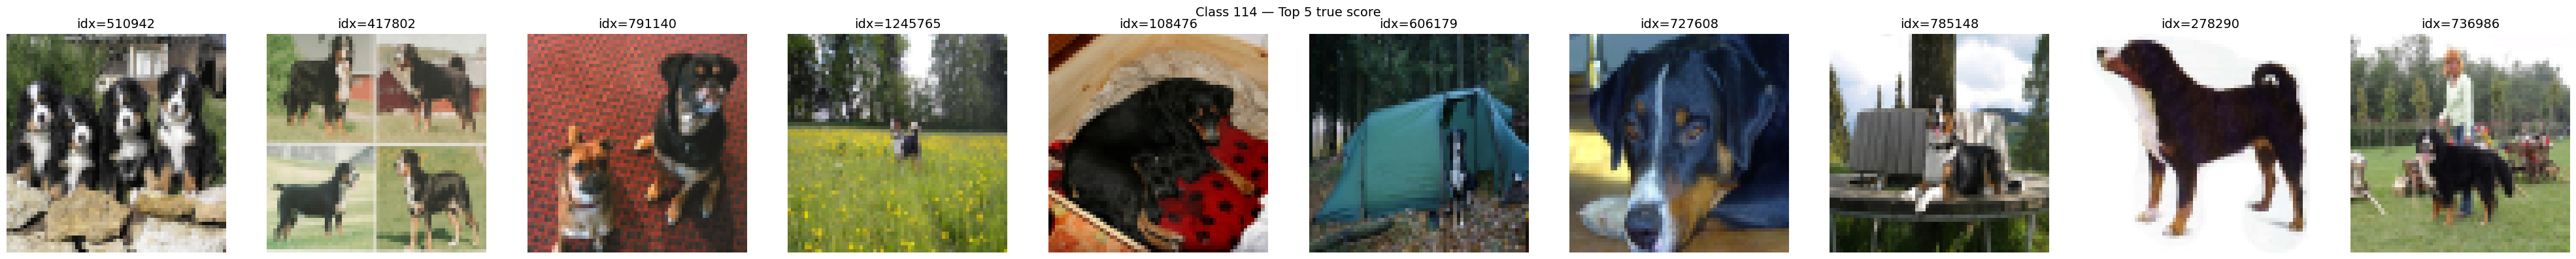

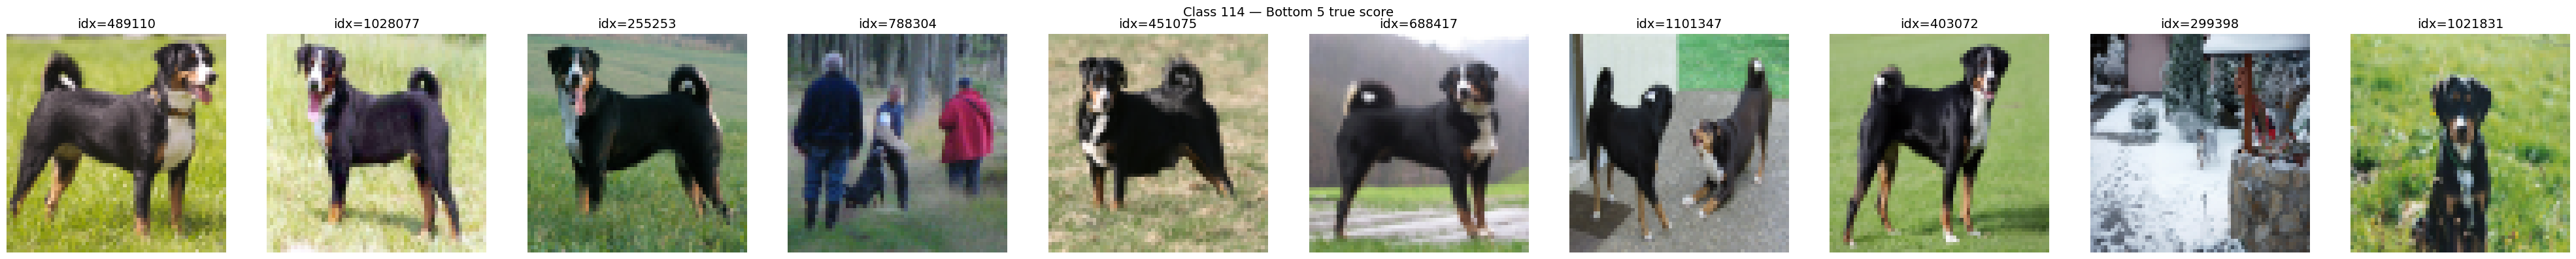

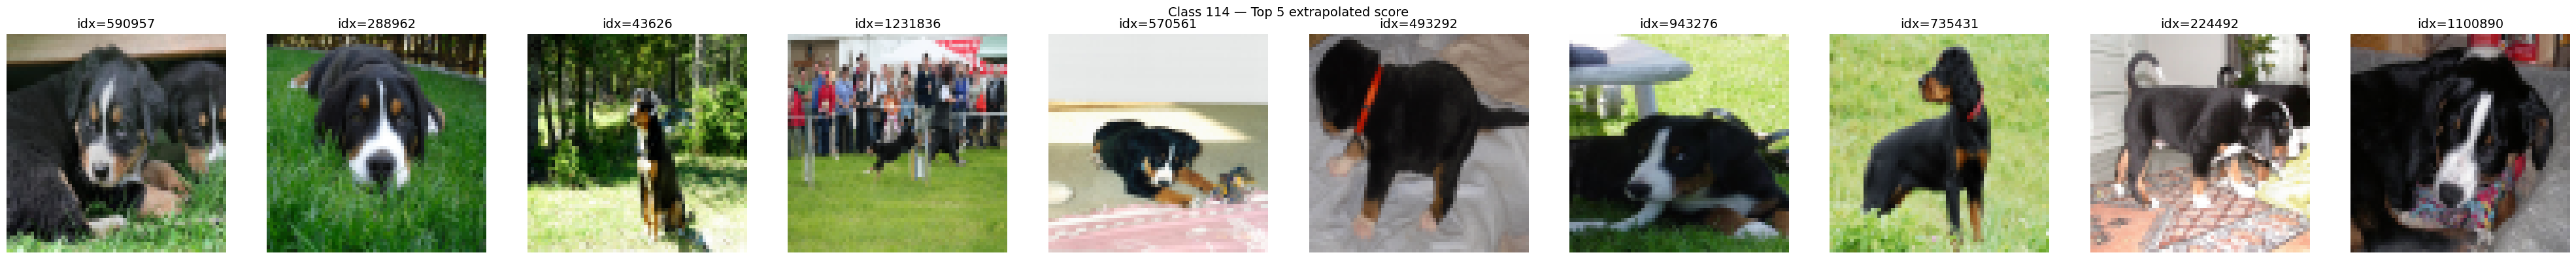

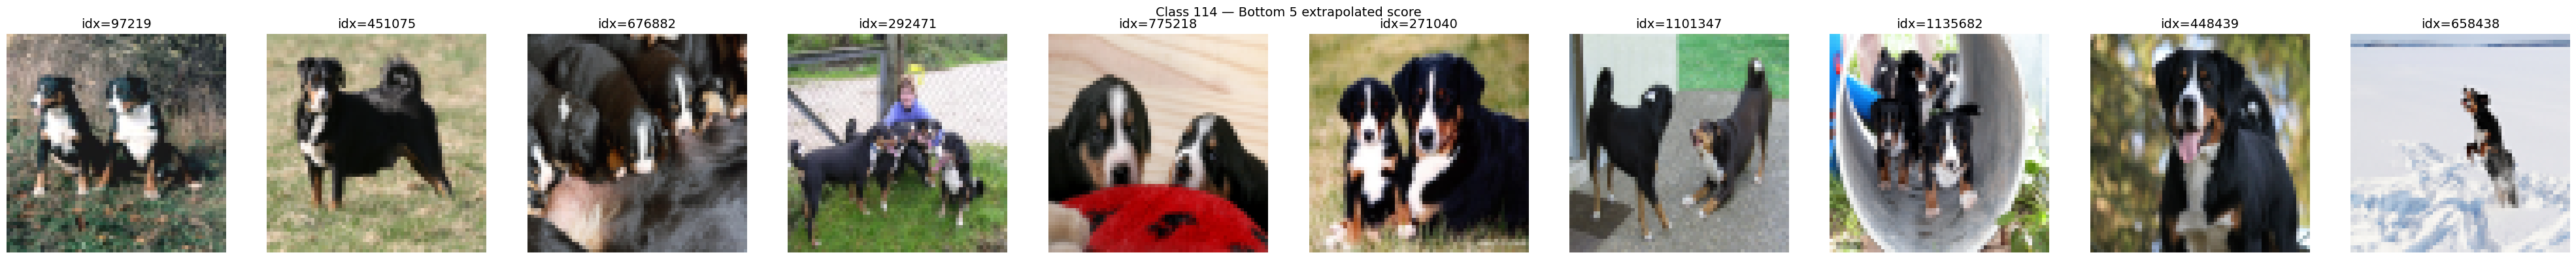

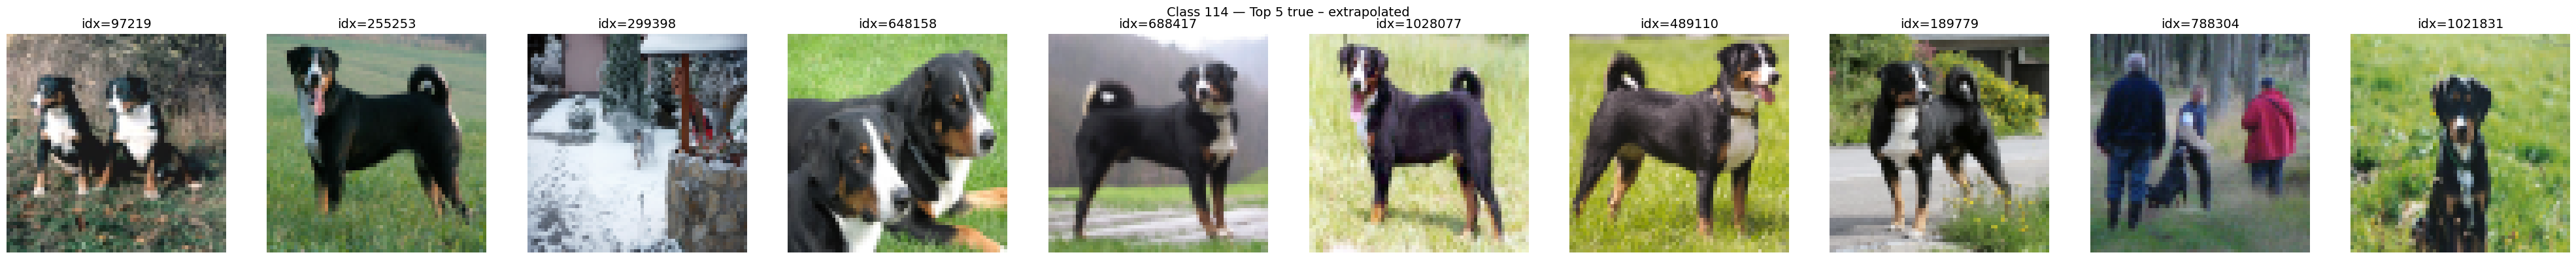

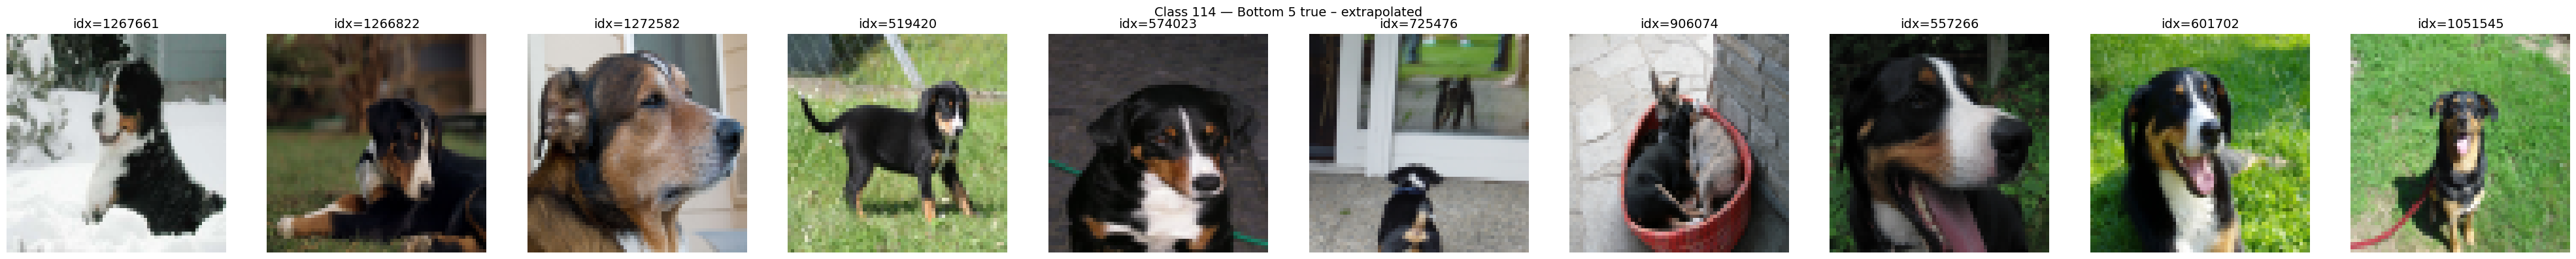

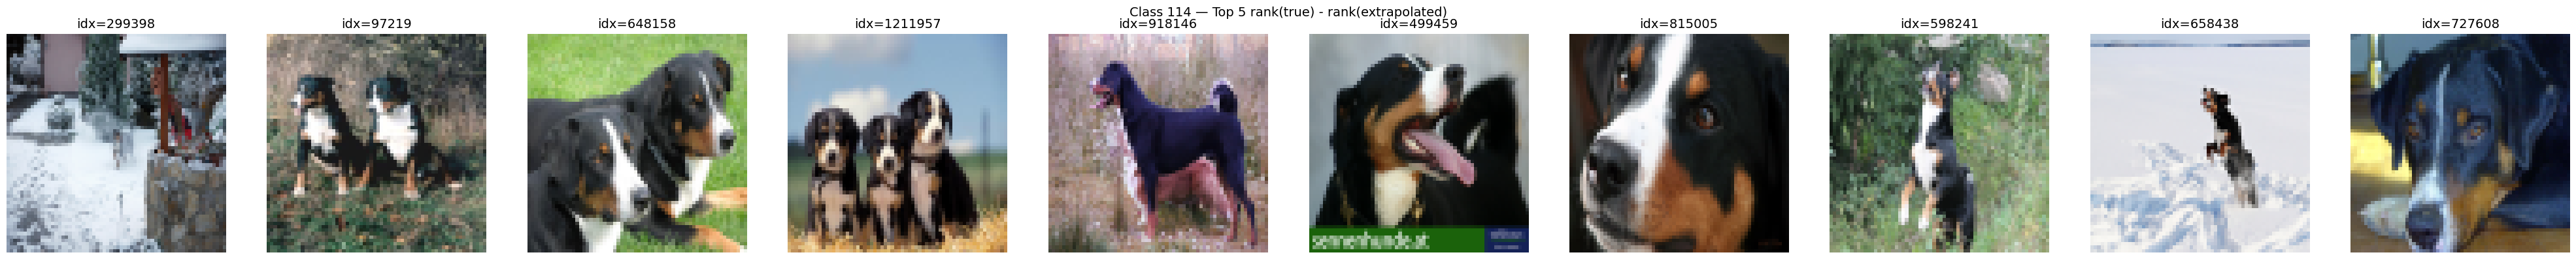

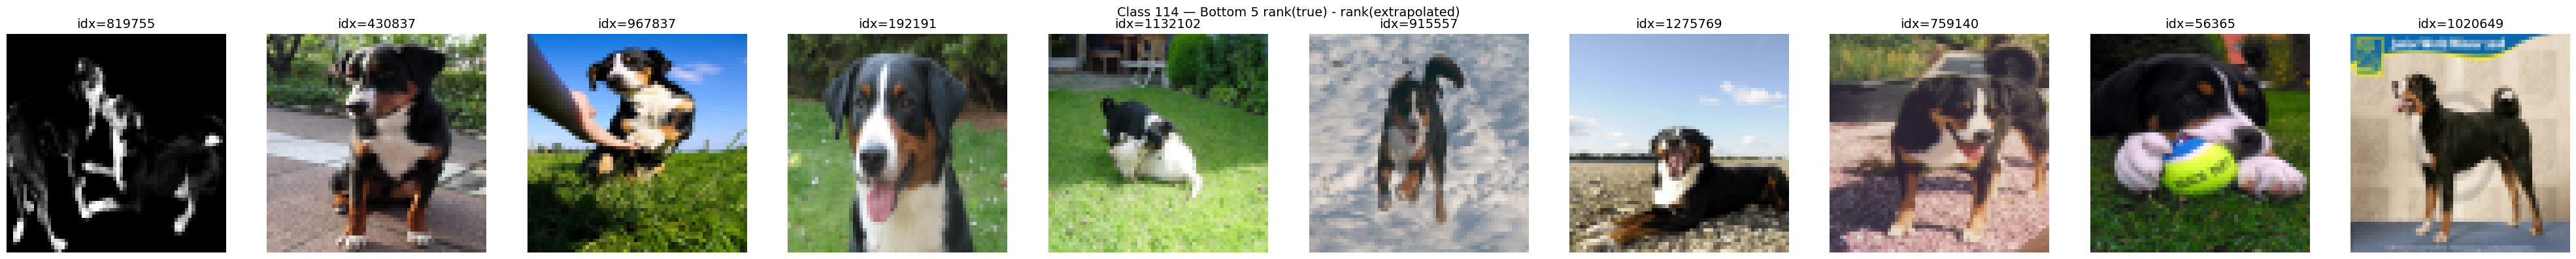

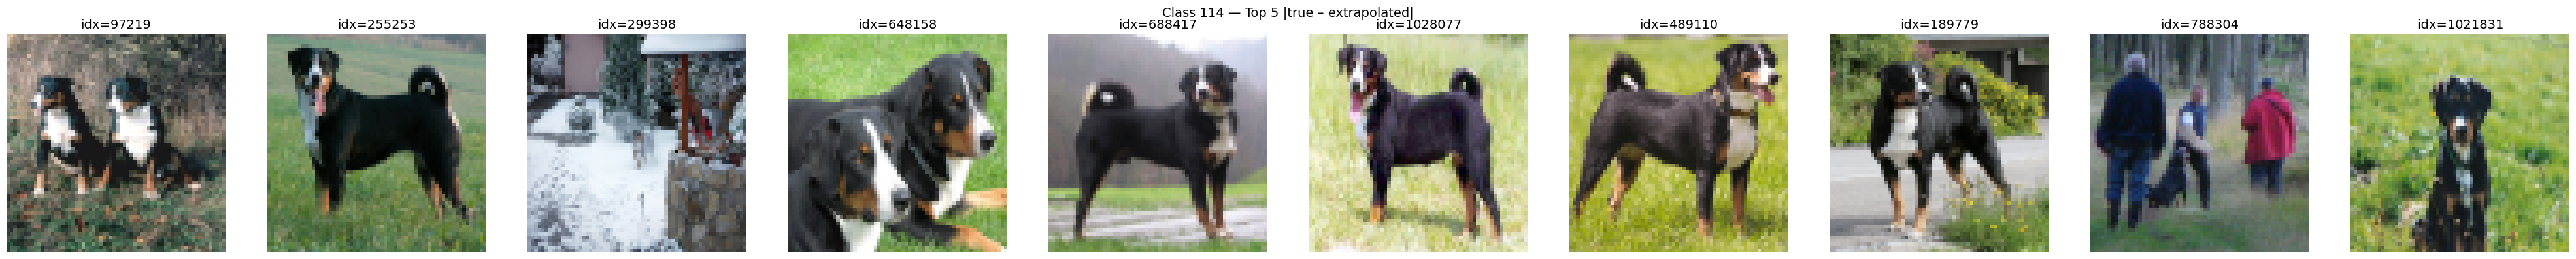

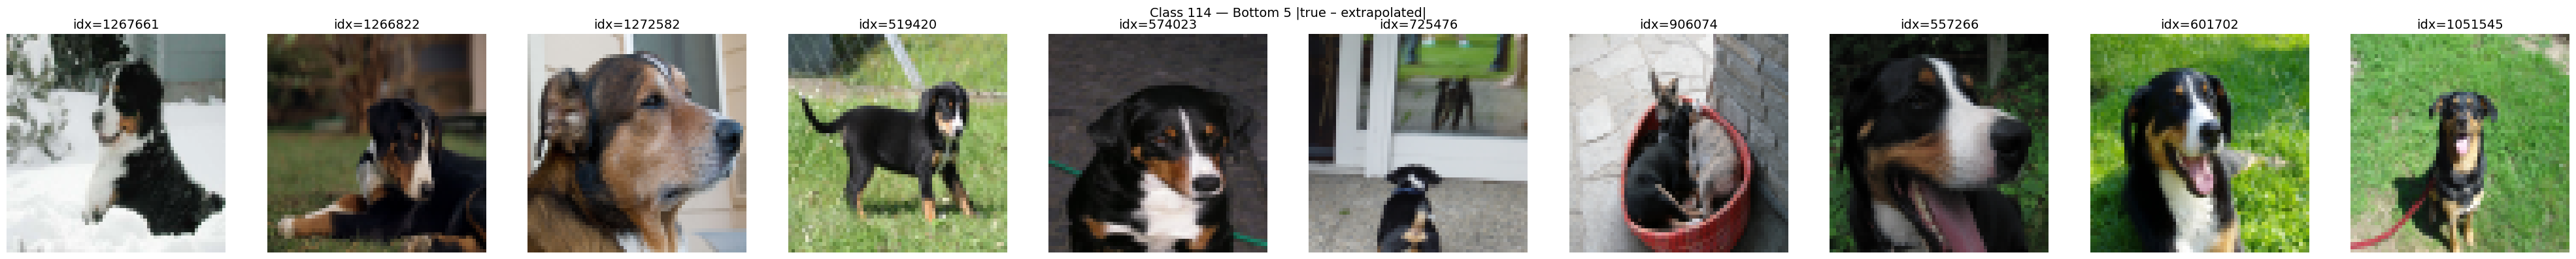

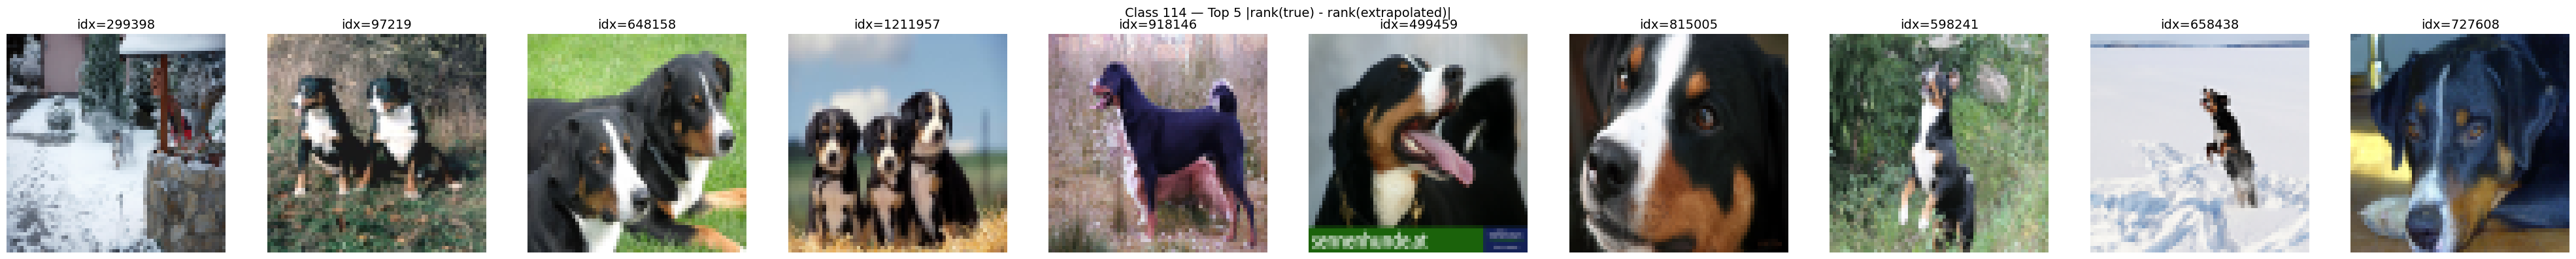

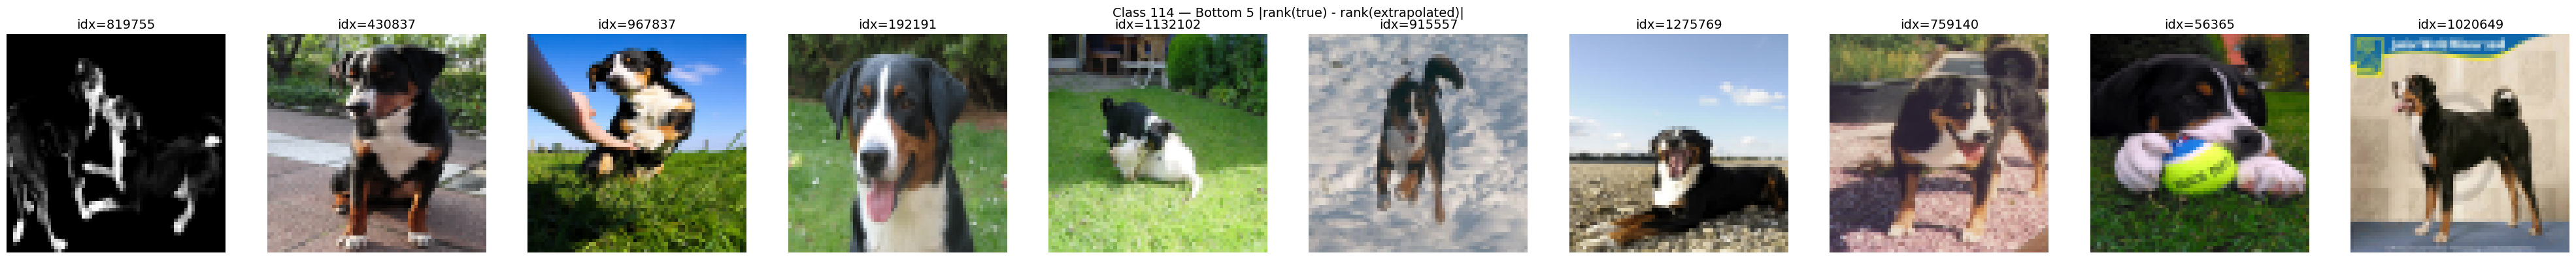

In [4]:
def plot_samples(title, idxs, dataset, mean, std, figsize=4):
    """
    dataset: your CustomDatasetWithIndices
    mean, std: tuples of length 3 (e.g. mean_imagenet, std_imagenet)
    idx2label: list where idx2label[label] is the class name string
    """
    fig, axes = plt.subplots(1, len(idxs), figsize=(len(idxs)*figsize, figsize))
    for ax, idx in zip(axes, idxs):
        img, label, orig_index = dataset[idx]
        # undo normalization
        img = img.clone()
        for c, (m, s) in enumerate(zip(mean, std)):
            img[c] = img[c] * s + m
        img = torch.clamp(img, 0, 1)
        # HWC for imshow
        img = img.permute(1, 2, 0).cpu().numpy()

        ax.imshow(img)
        ax.set_title(f"idx={idx}", fontsize=14)
        ax.axis("off")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

mean_imagenet = (0.449, 0.426, 0.379)
std_imagenet = (0.285, 0.276, 0.284)

all_classes = torch.unique(labels_tensor).tolist()
random.seed(42)
sampled_classes = random.sample(all_classes, 20)

for cls in [114]:
    # get all sample‐idxs of this class
    cls_idxs = (labels_tensor == cls).nonzero(as_tuple=True)[0].cpu().numpy()
    
    # collect scores & ranks for these idxs
    full_scores = np.array([full_scores_dict[str(i)] for i in cls_idxs])
    ext_scores  = np.array([extrapolated_scores_dict[str(i)] for i in cls_idxs])
    full_ranks  = np.array([full_scores_ranks[str(i)] for i in cls_idxs])
    ext_ranks   = np.array([extrapolated_scores_ranks[str(i)] for i in cls_idxs])
    
    num_images = 10
    top5_full    = cls_idxs[np.argsort(full_scores)[-num_images:][::-1]]
    bot5_full    = cls_idxs[np.argsort(full_scores)[:num_images]]
    
    # top/bottom 5 by extrapolated score
    top5_ext     = cls_idxs[np.argsort(ext_scores)[-num_images:][::-1]]
    bot5_ext     = cls_idxs[np.argsort(ext_scores)[:num_images]]
    
    # by absolute score diff
    score_diff_abs   = np.abs(full_scores - ext_scores)
    top5_sdiff_abs   = cls_idxs[np.argsort(score_diff_abs)[-num_images:][::-1]]
    bot5_sdiff_abs   = cls_idxs[np.argsort(score_diff_abs)[:num_images]]
    
    # by rank diff
    rank_diff_abs    = np.abs(full_ranks - ext_ranks)
    top5_rdiff_abs   = cls_idxs[np.argsort(rank_diff_abs)[-num_images:][::-1]]
    bot5_rdiff_abs   = cls_idxs[np.argsort(rank_diff_abs)[:num_images]]

    score_diff   = np.abs(full_scores - ext_scores)
    top5_sdiff   = cls_idxs[np.argsort(score_diff)[-num_images:][::-1]]
    bot5_sdiff   = cls_idxs[np.argsort(score_diff)[:num_images]]
    
    # by rank diff
    rank_diff    = np.abs(full_ranks - ext_ranks)
    top5_rdiff   = cls_idxs[np.argsort(rank_diff)[-num_images:][::-1]]
    bot5_rdiff   = cls_idxs[np.argsort(rank_diff)[:num_images]]

    # now plot each group
    print(f"\n\n===== Class {cls} =====")
    
    plot_samples(f"Class {cls} — Top 5 true score",   top5_full,  trainset, mean_imagenet, std_imagenet)
    plot_samples(f"Class {cls} — Bottom 5 true score", bot5_full,  trainset, mean_imagenet, std_imagenet)
    
    plot_samples(f"Class {cls} — Top 5 extrapolated score",   top5_ext, trainset, mean_imagenet, std_imagenet)
    plot_samples(f"Class {cls} — Bottom 5 extrapolated score", bot5_ext, trainset, mean_imagenet, std_imagenet)
    
    plot_samples(f"Class {cls} — Top 5 true – extrapolated",   top5_sdiff, trainset, mean_imagenet, std_imagenet)
    plot_samples(f"Class {cls} — Bottom 5 true – extrapolated",bot5_sdiff, trainset, mean_imagenet, std_imagenet)
    
    plot_samples(f"Class {cls} — Top 5 rank(true) - rank(extrapolated)",   top5_rdiff, trainset, mean_imagenet, std_imagenet)
    plot_samples(f"Class {cls} — Bottom 5 rank(true) - rank(extrapolated)",bot5_rdiff, trainset, mean_imagenet, std_imagenet)

    plot_samples(f"Class {cls} — Top 5 |true – extrapolated|",   top5_sdiff_abs, trainset, mean_imagenet, std_imagenet)
    plot_samples(f"Class {cls} — Bottom 5 |true – extrapolated|",bot5_sdiff_abs, trainset, mean_imagenet, std_imagenet)
    
    plot_samples(f"Class {cls} — Top 5 |rank(true) - rank(extrapolated)|",   top5_rdiff_abs, trainset, mean_imagenet, std_imagenet)
    plot_samples(f"Class {cls} — Bottom 5 |rank(true) - rank(extrapolated)|",bot5_rdiff_abs, trainset, mean_imagenet, std_imagenet)

In [7]:
print(top5_sdiff_abs[:5])
print(bot5_sdiff_abs[:5])

[ 97219 255253 299398 648158 688417]
[1267661 1266822 1272582  519420  574023]


In [6]:
print(top5_rdiff_abs[:5])
print(bot5_rdiff_abs[:5])

[ 299398   97219  648158 1211957  918146]
[ 819755  430837  967837  192191 1132102]


In [5]:
import matplotlib.pyplot as plt
import torch

def plot_top_bottom(
    cls,
    top_idxs,
    bot_idxs,
    dataset,
    mean,
    std,
    figsize=(10, 4),
    dpi=300,
    save_path=None,
):
    """
    Plots two rows of 5 images each (top-scoring and bottom-scoring) 
    with no gaps, for inclusion in a paper.

    cls:        class identifier to show in the suptitle
    top_idxs:   list of 5 indices for the highest-scoring samples
    bot_idxs:   list of 5 indices for the lowest-scoring samples
    dataset:    your CustomDatasetWithIndices
    mean, std:  normalization stats (tuples of length 3)
    figsize:    overall figure size in inches, default (10×4)
    dpi:        resolution for saving
    save_path:  if given, save PDF/PNG here
    """
    # Create 2×5 grid
    fig, axes = plt.subplots(
        nrows=1, ncols=5,
        figsize=figsize, dpi=dpi,
        gridspec_kw=dict(wspace=0.01, hspace=0.01)
    )

    for row, idxs, row_title in zip(
        [0, 1],
        [top_idxs, bot_idxs],
        ['Top 5 true score', 'Bottom 5 true score']
    ):
        for col, idx in enumerate(idxs):
            ax = axes[row, col]
            img, label, orig_index = dataset[idx]
            # undo normalization
            img = img.clone()
            for c, (m, s) in enumerate(zip(mean, std)):
                img[c] = img[c] * s + m
            img = torch.clamp(img, 0, 1)
            img = img.permute(1, 2, 0).cpu().numpy()
            ax.imshow(img)
            ax.axis('off')

    # plt.tight_layout(pad=0)

    if save_path:
        plt.savefig("images.png", bbox_inches='tight')
    plt.show()


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

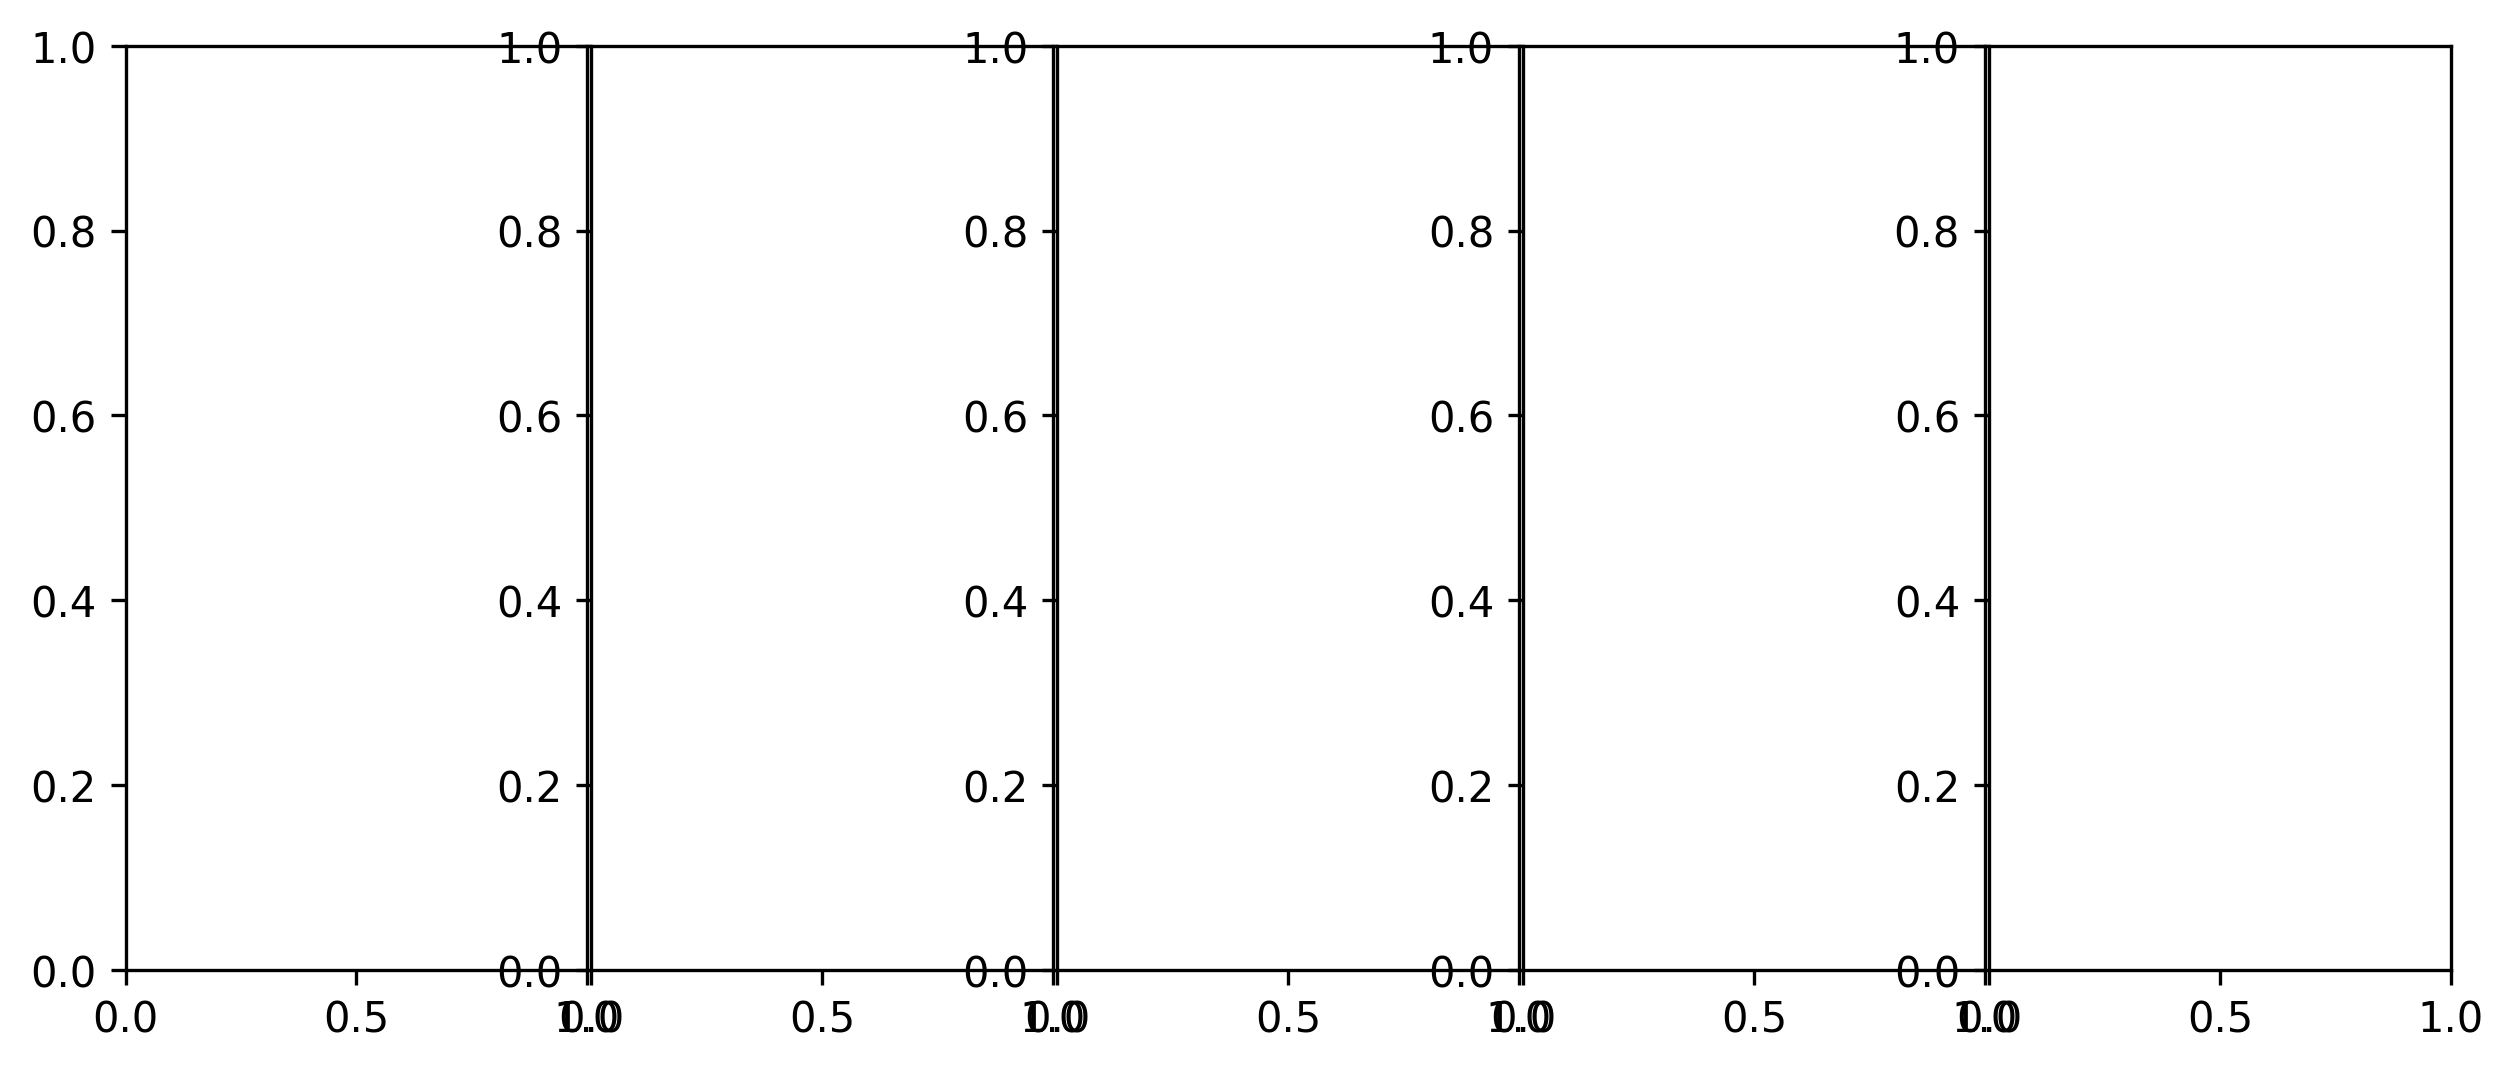

In [6]:
plot_top_bottom(
    cls=cls,
    top_idxs=top5_full[:5],
    bot_idxs=bot5_full[:5],
    dataset=trainset,
    mean=mean_imagenet,
    std=std_imagenet,
    figsize=(10, 4),
    save_path=f"figures/class_{cls}_examples.pdf"
)


In [10]:

def plot_row(
    idxs,
    dataset,
    mean,
    std,
    title,
    save_path=None,
    figsize=(6, 2),
    dpi=300,
):
    """
    Plots one row of images (here len(idxs) columns) with no gaps.
    """
    n = len(idxs)
    fig, axes = plt.subplots(
        nrows=1, ncols=n,
        figsize=figsize, dpi=dpi,
        gridspec_kw=dict(wspace=0.01, hspace=0.01)
    )

    for col, idx in enumerate(idxs):
        ax = axes[col]
        img, label, orig_index = dataset[idx]
        # undo normalization
        img = img.clone()
        for c, (m, s) in enumerate(zip(mean, std)):
            img[c] = img[c] * s + m
        img = torch.clamp(img, 0, 1)
        img = img.permute(1, 2, 0).cpu().numpy()
        ax.imshow(img)
        ax.axis('off')

    plt.tight_layout(pad=0)
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        plt.close(fig)
    else:
        plt.show()

# Then simply call it twice:
plot_row(
    top5_full[:3],
    trainset,
    mean_imagenet,
    std_imagenet,
    title="Top 5 true score",
    save_path="high.png",
    figsize=(6, 2)
)
plot_row(
    bot5_full[:3],
    trainset,
    mean_imagenet,
    std_imagenet,
    title="Bottom 5 true score",
    save_path="low.png",
    figsize=(6, 2)
)


/tmp/ipykernel_978224/1638767184.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0)


In [ ]:

cfg = OmegaConf.load("/nfs/homedirs/dhp/unsupervised-data-pruning/src/extrapolate/configs/gnn_config.yaml")
cfg = cfg.CIFAR10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

trainset, train_loader, _, num_samples = prepare_data(cfg.dataset, 1024)

with open("/nfs/homedirs/dhp/unsupervised-data-pruning/scores/prune/CIFAR10_dynamic_uncertainty_0.json") as f:
    full_scores_dict = json.load(f)

with open("/nfs/homedirs/dhp/unsupervised-data-pruning/scores/extrapolation/extrapolated/gnn_DU_CIFAR10_resnet50-self-trained_k_10_seed_20000_euclidean.json") as f:
    extrapolated_scores_dict = json.load(f)

labels_tensor = torch.zeros(num_samples, dtype=torch.int64, device=device)

sample_input, _, _ = trainset[0]  # first sample, ignore label & idx
sample_input = sample_input.unsqueeze(0).to(device)

for _, labels, sample_idxs in tqdm(
    train_loader, mininterval=20, maxinterval=40
):
    sample_idxs = sample_idxs.to(device)
    labels = labels.to(device)
    labels_tensor[sample_idxs] = labels

full_scores_dict_sorted = dict(sorted(full_scores_dict.items(), key=lambda item: item[1]))
extrapolated_scores_dict_sorted = dict(
    sorted(extrapolated_scores_dict.items(), key=lambda item: item[1])
)
full_scores_ranks = {
    k: i for i, k in enumerate(full_scores_dict_sorted.keys())
}
extrapolated_scores_ranks = {
    k: i for i, k in enumerate(extrapolated_scores_dict_sorted.keys())
}




In [ ]:
# helper to unnormalize a single tensor image: C×H×W
def unnormalize(img, mean, std):
    """
    img: torch.Tensor in [-mean/std, (1-mean)/std], C×H×W
    mean: tuple of length C
    std:  tuple of length C
    """
    img = img.clone()
    for c, (m, s) in enumerate(zip(mean, std)):
        img[c] = img[c] * s + m
    return torch.clamp(img, 0.0, 1.0)

# updated plot helper
def plot_samples(title, idxs, trainset, mean, std):
    fig, axes = plt.subplots(1, len(idxs), figsize=(len(idxs)*1, 1))
    for ax, idx in zip(axes, idxs):
        img, label, _ = trainset[idx]
        img = unnormalize(img, mean, std)
        img = img.permute(1,2,0).cpu().numpy()
        ax.imshow(img)
        ax.set_title(f"idx={idx}")
        ax.axis('off')

    fig.suptitle(title, fontsize=10)
    plt.tight_layout()
    plt.show()

mean_cifar10 = (0.4914, 0.4822, 0.4465)
std_cifar10  = (0.2470, 0.2435, 0.2616)



all_classes = torch.unique(labels_tensor).tolist()
random.seed(42)
sampled_classes = random.sample(all_classes, 5)

for cls in sampled_classes:
    # get all sample‐idxs of this class
    cls_idxs = (labels_tensor == cls).nonzero(as_tuple=True)[0].cpu().numpy()
    
    # collect scores & ranks for these idxs
    full_scores = np.array([full_scores_dict[str(i)] for i in cls_idxs])
    ext_scores  = np.array([extrapolated_scores_dict[str(i)] for i in cls_idxs])
    full_ranks  = np.array([full_scores_ranks[str(i)] for i in cls_idxs])
    ext_ranks   = np.array([extrapolated_scores_ranks[str(i)] for i in cls_idxs])
    
    # top/bottom 5 by full score
    top5_full    = cls_idxs[np.argsort(full_scores)[-5:][::-1]]
    bot5_full    = cls_idxs[np.argsort(full_scores)[:5]]
    
    # top/bottom 5 by extrapolated score
    top5_ext     = cls_idxs[np.argsort(ext_scores)[-5:][::-1]]
    bot5_ext     = cls_idxs[np.argsort(ext_scores)[:5]]
    
    # by absolute score diff
    score_diff   = np.abs(full_scores - ext_scores)
    top5_sdiff   = cls_idxs[np.argsort(score_diff)[-5:][::-1]]
    bot5_sdiff   = cls_idxs[np.argsort(score_diff)[:5]]
    
    # by rank diff
    rank_diff    = np.abs(full_ranks - ext_ranks)
    top5_rdiff   = cls_idxs[np.argsort(rank_diff)[-5:][::-1]]
    bot5_rdiff   = cls_idxs[np.argsort(rank_diff)[:5]]
    
    # now plot each group
    print(f"\n\n===== Class {cls} =====")
    
    plot_samples(f"Class {cls} — Top 5 full‐score",   top5_full,  trainset, mean_cifar10, std_cifar10)
    plot_samples(f"Class {cls} — Bottom 5 full‐score",bot5_full,  trainset, mean_cifar10, std_cifar10)
    
    plot_samples(f"Class {cls} — Top 5 extrapolated‐score",   top5_ext, trainset, mean_cifar10, std_cifar10)
    plot_samples(f"Class {cls} — Bottom 5 extrapolated‐score",bot5_ext, trainset, mean_cifar10, std_cifar10)
    
    plot_samples(f"Class {cls} — Top 5 |full–ext|",   top5_sdiff, trainset, mean_cifar10, std_cifar10)
    plot_samples(f"Class {cls} — Bottom 5 |full–ext|",bot5_sdiff, trainset, mean_cifar10, std_cifar10)
    
    plot_samples(f"Class {cls} — Top 5 rank‐diff",   top5_rdiff, trainset, mean_cifar10, std_cifar10)
    plot_samples(f"Class {cls} — Bottom 5 rank‐diff",bot5_rdiff, trainset, mean_cifar10, std_cifar10)
